In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))
import matplotlib.pyplot as plt
from models import BaseLevelEvaluator
import pandas as pd
from scipy.stats import friedmanchisquare
import scikit_posthocs as sp

/home/henriqueramos_qs/meta-learning-concept-drift/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
FINAL_FEATURE_FRACTION = {'powersupply': 50,
                           'airlines': 65,
                            'electricity': 15,
                             'rialto': 10}

DATASETS = [
    "airlines",
    "electricity",
    "powersupply",
    "rialto"
]

METRICS = ["kappa", "precision","recall", "f1-score"]

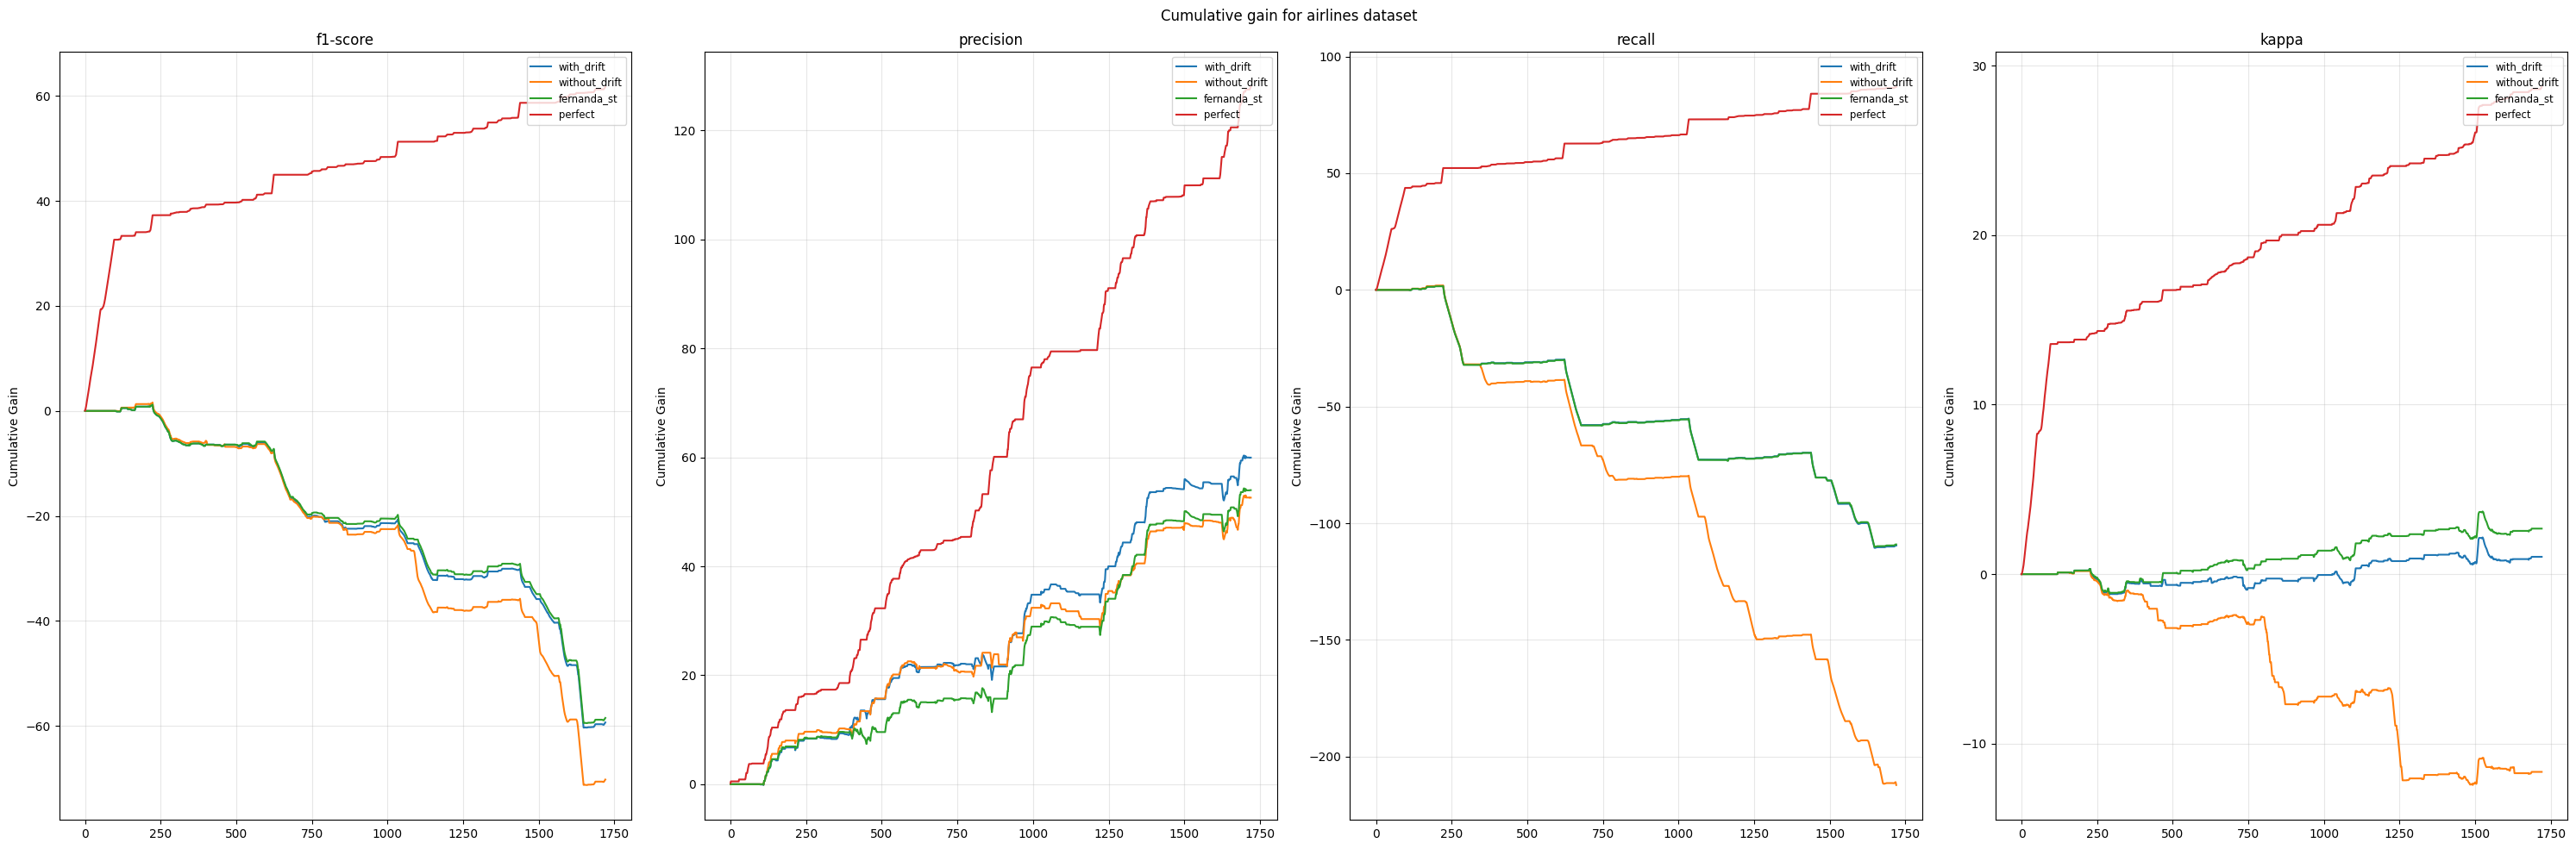

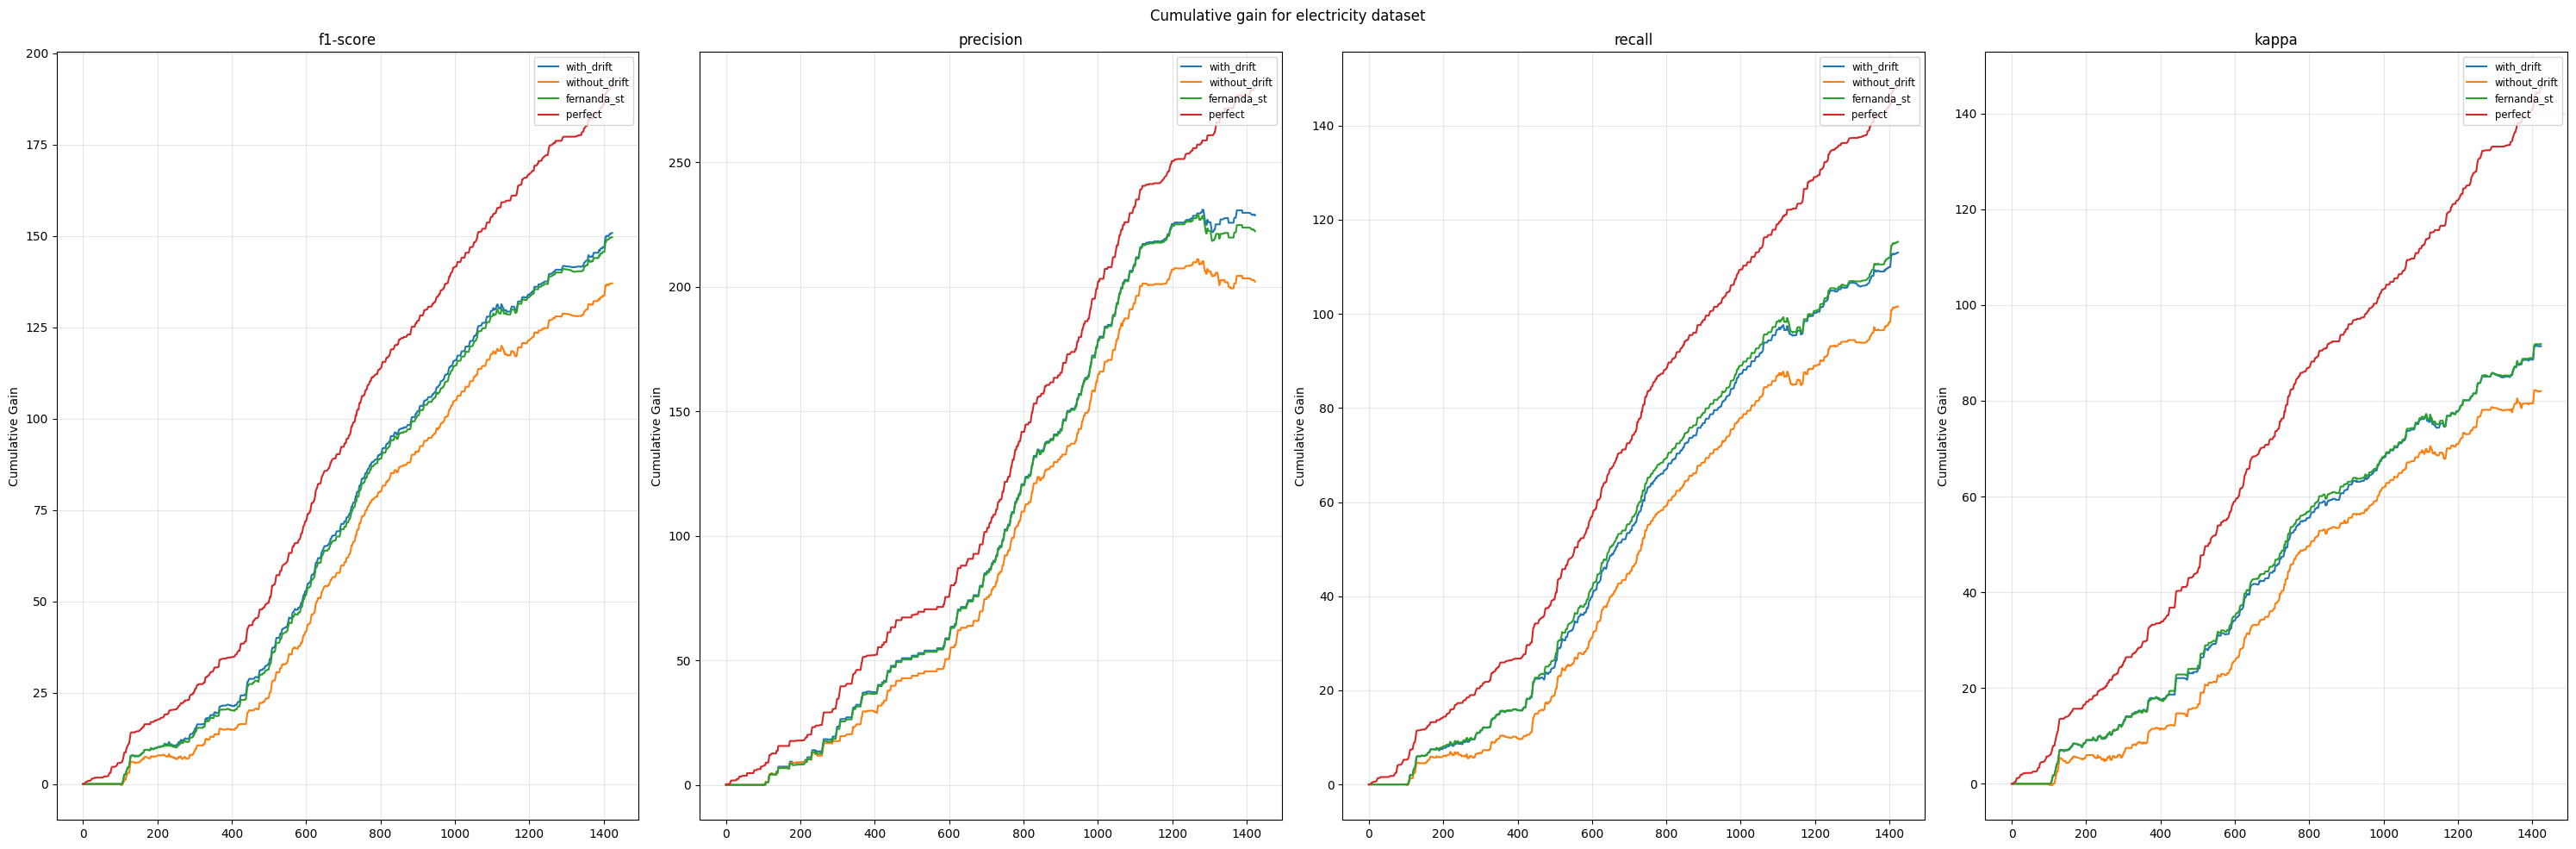

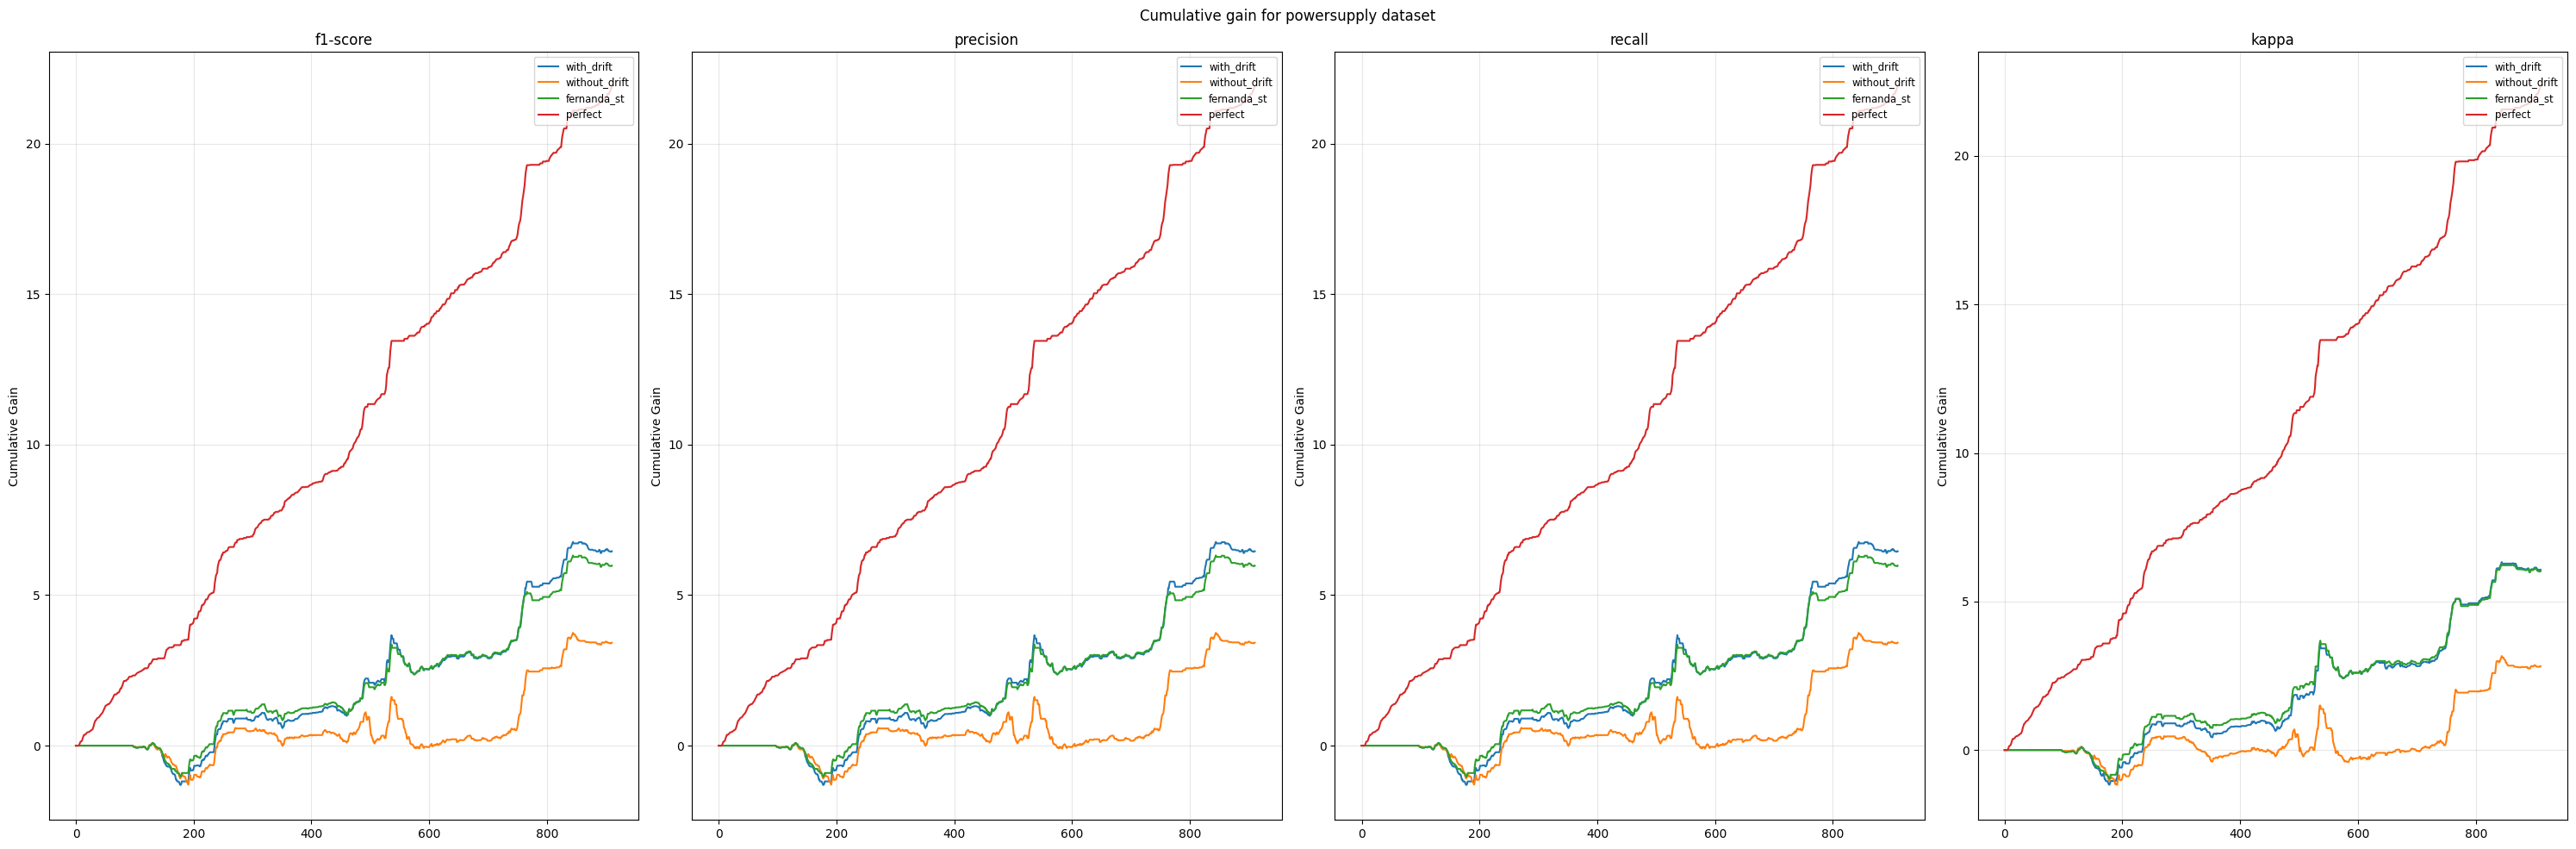

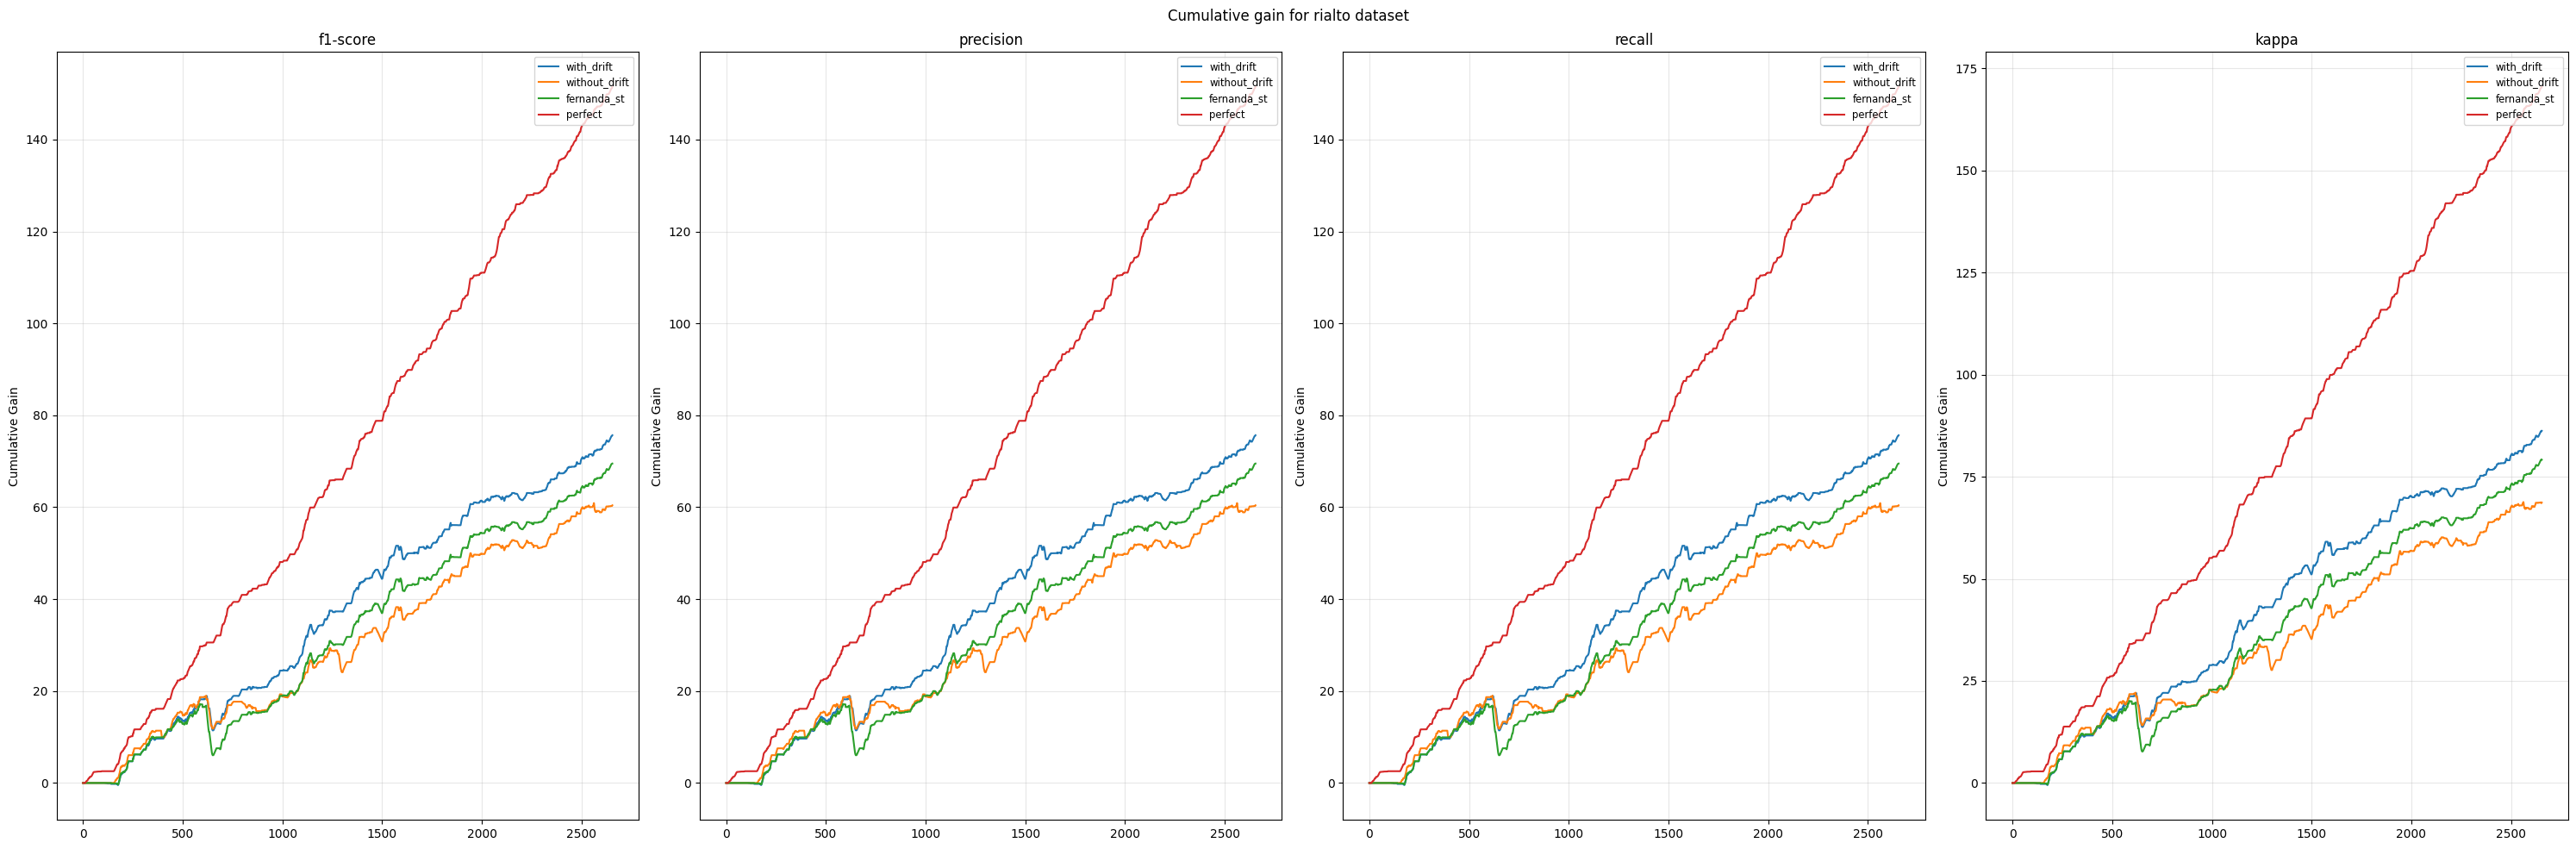

In [3]:

evaluators = {
    ds: BaseLevelEvaluator(ds,feature_fraction=100) for ds in DATASETS
}

for ds, eval in evaluators.items():
    eval.plot_charts()

In [4]:
hyp_test_dfs={
    metric:  pd.concat(
        [evaluators[ds].methods_perfomances[metric] for ds in DATASETS]
    ) for metric in METRICS
} 


In [5]:
for metric, df in hyp_test_dfs.items():
    transposed_results = df.T
    print(df.columns)
    baseline = transposed_results.loc['baseline_performance'].values
    with_drift = transposed_results.loc['with_drift_performance'].values
    without_drift = transposed_results.loc['without_drift_performance'].values
    perfect = transposed_results.loc['perfect_performance'].values

    friedman_statistics, friedman_p_value= friedmanchisquare(baseline,with_drift,without_drift,perfect)
    print(f"Friedman Statistics: {friedman_statistics}")
    print(f"Friedman p-value: {friedman_p_value}")

Index(['with_drift_performance', 'without_drift_performance',
       'fernanda_st_performance', 'baseline_performance',
       'perfect_performance'],
      dtype='object')
Friedman Statistics: 4861.166309596132
Friedman p-value: 0.0
Index(['with_drift_performance', 'without_drift_performance',
       'fernanda_st_performance', 'baseline_performance',
       'perfect_performance'],
      dtype='object')
Friedman Statistics: 4106.822553959551
Friedman p-value: 0.0
Index(['with_drift_performance', 'without_drift_performance',
       'fernanda_st_performance', 'baseline_performance',
       'perfect_performance'],
      dtype='object')
Friedman Statistics: 4557.931384883379
Friedman p-value: 0.0
Index(['with_drift_performance', 'without_drift_performance',
       'fernanda_st_performance', 'baseline_performance',
       'perfect_performance'],
      dtype='object')
Friedman Statistics: 4728.425618569327
Friedman p-value: 0.0


In [6]:
for metric, df in hyp_test_dfs.items():
    # print(f"nemenyi_results for {metric}")
    nemenyi_results = sp.posthoc_nemenyi_friedman(df)
    # alpha = 0.05
    # print(nemenyi_results<alpha)
    # print("\n")
    styled_df= nemenyi_results.style.map(
        lambda val: 'background-color: #002D54' if val < 0.05 else ''
    ).format("{:.2e}")
    
    print(f"Nemeyni for {metric}:")
    display(styled_df) # Use

Nemeyni for kappa:


,with_drift_performance,without_drift_performance,fernanda_st_performance,baseline_performance,perfect_performance
with_drift_performance,1.00e+00,2.39e-03,1.00e+00,0.00e+00,0.00e+00
without_drift_performance,2.39e-03,1.00e+00,1.57e-03,1.11e-16,0.00e+00
fernanda_st_performance,1.00e+00,1.57e-03,1.00e+00,0.00e+00,0.00e+00
baseline_performance,0.00e+00,1.11e-16,0.00e+00,1.00e+00,0.00e+00
perfect_performance,0.00e+00,0.00e+00,0.00e+00,0.00e+00,1.00e+00


Nemeyni for precision:


,with_drift_performance,without_drift_performance,fernanda_st_performance,baseline_performance,perfect_performance
with_drift_performance,1.00e+00,5.20e-02,9.75e-01,0.00e+00,0.00e+00
without_drift_performance,5.20e-02,1.00e+00,2.16e-01,0.00e+00,0.00e+00
fernanda_st_performance,9.75e-01,2.16e-01,1.00e+00,0.00e+00,0.00e+00
baseline_performance,0.00e+00,0.00e+00,0.00e+00,1.00e+00,0.00e+00
perfect_performance,0.00e+00,0.00e+00,0.00e+00,0.00e+00,1.00e+00


Nemeyni for recall:


,with_drift_performance,without_drift_performance,fernanda_st_performance,baseline_performance,perfect_performance
with_drift_performance,1.00e+00,5.09e-08,1.00e+00,0.00e+00,0.00e+00
without_drift_performance,5.09e-08,1.00e+00,2.63e-08,7.77e-16,0.00e+00
fernanda_st_performance,1.00e+00,2.63e-08,1.00e+00,0.00e+00,0.00e+00
baseline_performance,0.00e+00,7.77e-16,0.00e+00,1.00e+00,0.00e+00
perfect_performance,0.00e+00,0.00e+00,0.00e+00,0.00e+00,1.00e+00


Nemeyni for f1-score:


,with_drift_performance,without_drift_performance,fernanda_st_performance,baseline_performance,perfect_performance
with_drift_performance,1.00e+00,3.10e-02,9.82e-01,0.00e+00,0.00e+00
without_drift_performance,3.10e-02,1.00e+00,1.30e-01,8.06e-11,0.00e+00
fernanda_st_performance,9.82e-01,1.30e-01,1.00e+00,0.00e+00,0.00e+00
baseline_performance,0.00e+00,8.06e-11,0.00e+00,1.00e+00,0.00e+00
perfect_performance,0.00e+00,0.00e+00,0.00e+00,0.00e+00,1.00e+00
